In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load your dataset (assuming it's a CSV)
df = pd.read_csv('data/Property_Assessment_Data.csv')

# See how many rows and columns you have
print(f"Dataset Shape: {df.shape}")

# Look at the first 5 rows to understand what the data looks like
display(df.head())

# Check the data types and see which columns have missing data
df.info()

/var/folders/6b/d0cp077s7hq5hchkmy0sz6f80000gn/T/ipykernel_57511/3940205342.py:6: DtypeWarning: Columns (0: Suite, 1: Assessment Class 3) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('Property_Assessment_Data.csv')


Dataset Shape: (5501958, 21)


,Account Number,Assessment Year,Suite,House Number,Street Name,Legal Description,Latitude,Longitude,Point Location,Neighbourhood,...,Garage,Zoning,Lot Size,Assessed Value,Assessment Class 1,Assessment Class % 1,Assessment Class 2,Assessment Class % 2,Assessment Class 3,Assessment Class % 3
0,1477850,2013,NaN,10821.0,150 STREET NW,Plan: 704KS Block: 68 Lot: 5,53.55330,-113.57936,POINT (-113.57936 53.5533),HIGH PARK,...,Y,RF1,681.1240,"$269,500.00",RESIDENTIAL,100.0,NaN,NaN,NaN,NaN
1,1437631,2017,NaN,16101.0,107A AVENUE NW,Plan: 3711KS Block: 29 Lot: 12,53.55166,-113.59871,POINT (-113.59871 53.55166),MAYFIELD,...,Y,RF1,510.7670,"$324,000.00",RESIDENTIAL,100.0,NaN,NaN,NaN,NaN
2,1457910,2018,NaN,10603.0,153 STREET NW,Plan: 4592AD Block: 34 Lot: 1,53.54966,-113.58460,POINT (-113.5846 53.54966),CANORA,...,Y,RF2,688.4160,"$326,500.00",RESIDENTIAL,100.0,NaN,NaN,NaN,NaN
3,1433606,2019,NaN,10720.0,166 STREET NW,Plan: 4330KS Block: 24 Lot: P,53.55200,-113.60757,POINT (-113.60757 53.552),MAYFIELD,...,N,RF1,"10,267.4470","$50,500.00",COMMERCIAL,100.0,NaN,NaN,NaN,NaN
4,1476985,2012,NaN,10604.0,149 STREET NW,Plan: 166HW Block: 66 Lot: 2,53.54993,-113.57860,POINT (-113.5786 53.54993),CANORA,...,N,AP,623.3980,"$3,000.00",COMMERCIAL,100.0,NaN,NaN,NaN,NaN


<class 'pandas.DataFrame'>
RangeIndex: 5501958 entries, 0 to 5501957
Data columns (total 21 columns):
 #   Column                Dtype  
---  ------                -----  
 0   Account Number        int64  
 1   Assessment Year       int64  
 2   Suite                 object 
 3   House Number          float64
 4   Street Name           str    
 5   Legal Description     str    
 6   Latitude              float64
 7   Longitude             float64
 8   Point Location        str    
 9   Neighbourhood         str    
 10  Actual Year Built     float64
 11  Garage                str    
 12  Zoning                str    
 13  Lot Size              str    
 14  Assessed Value        str    
 15  Assessment Class 1    str    
 16  Assessment Class % 1  float64
 17  Assessment Class 2    str    
 18  Assessment Class % 2  float64
 19  Assessment Class 3    str    
 20  Assessment Class % 3  float64
dtypes: float64(7), int64(2), object(1), str(11)
memory usage: 881.5+ MB


In [5]:
df_clean = df[df['Assessment Class 1'] == 'RESIDENTIAL'].copy()
# 1. Strip the dollar signs and commas, then convert to a float (number)
# The regex=True tells Pandas to look for both '$' and ',' symbols and replace them with nothing ''
df['Assessed Value'] = df['Assessed Value'].replace('[\$,]', '', regex=True).astype(float)

# Now you can safely run the filter!
df_clean = df[(df['Assessed Value'] >= 50000) & (df['Assessed Value'] <= 2500000)].copy()

<>:4: SyntaxWarning: invalid escape sequence '\$'
<>:4: SyntaxWarning: invalid escape sequence '\$'
/var/folders/6b/d0cp077s7hq5hchkmy0sz6f80000gn/T/ipykernel_57511/499178373.py:4: SyntaxWarning: invalid escape sequence '\$'
  df['Assessed Value'] = df['Assessed Value'].replace('[\$,]', '', regex=True).astype(float)


In [60]:
cols_to_drop = [
    'Account Number', 
    'Assessment Year', # Usually a constant if you downloaded the current roll
    'Suite', 
    'House Number', 
    'Street Name', 
    'Legal Description', 
    'Point Location', # Redundant because we have Lat/Lon
    'Assessment Class 1', 'Assessment Class % 1', # We already filtered using this
    'Assessment Class 2', 'Assessment Class % 2',
    'Assessment Class 3', 'Assessment Class % 3',
    'Neighbourhood', # Too granular for this analysis
]

# 4. Drop them
df_clean = df_clean.drop(columns=cols_to_drop, errors='ignore')
df_clean.head()

,Latitude,Longitude,Actual Year Built,Garage,Zoning,Lot Size,Assessed Value
0,53.55330,-113.57936,1955.0,Y,RF1,681.1240,269500.0
1,53.55166,-113.59871,1958.0,Y,RF1,510.7670,324000.0
2,53.54966,-113.58460,1953.0,Y,RF2,688.4160,326500.0
3,53.55200,-113.60757,1987.0,N,RF1,"10,267.4470",50500.0
5,53.55723,-113.58159,1950.0,N,RF1,568.8480,247500.0


In [61]:
df_clean = df_clean.dropna(subset=['Latitude', 'Longitude', 'Lot Size'])
median_year = df_clean['Actual Year Built'].median()
df_clean['Actual Year Built'] = df_clean['Actual Year Built'].fillna(median_year)
df_clean['Garage'] = df_clean['Garage'].fillna('N')
df_clean.head()

,Latitude,Longitude,Actual Year Built,Garage,Zoning,Lot Size,Assessed Value
0,53.55330,-113.57936,1955.0,Y,RF1,681.1240,269500.0
1,53.55166,-113.59871,1958.0,Y,RF1,510.7670,324000.0
2,53.54966,-113.58460,1953.0,Y,RF2,688.4160,326500.0
3,53.55200,-113.60757,1987.0,N,RF1,"10,267.4470",50500.0
5,53.55723,-113.58159,1950.0,N,RF1,568.8480,247500.0


In [69]:
# Convert text columns into 1s and 0s
categorical_cols = ['Zoning', 'Garage']

# drop_first=True prevents a statistical issue called multicollinearity 
# (e.g., if Garage_Y is 0, we already know they don't have a garage, so we don't need a Garage_N column)
df_ml_ready = pd.get_dummies(df_clean, columns=categorical_cols, drop_first=True)

print(f"Old column count: {len(df_clean.columns)}")
print(f"New column count: {len(df_ml_ready.columns)}")
df_ml_ready.head()

Old column count: 7
New column count: 141


,Latitude,Longitude,Actual Year Built,Lot Size,Assessed Value,Zoning_AED,Zoning_AES,Zoning_AG,Zoning_AGI,Zoning_AGU,...,Zoning_TMU,Zoning_TSDR,Zoning_TSLR,Zoning_UC3ES,Zoning_UCRH,Zoning_UF,Zoning_UI,Zoning_US,Zoning_UW,Garage_Y
0,53.55330,-113.57936,1955.0,681.1240,269500.0,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,True
1,53.55166,-113.59871,1958.0,510.7670,324000.0,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,True
2,53.54966,-113.58460,1953.0,688.4160,326500.0,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,True
3,53.55200,-113.60757,1987.0,"10,267.4470",50500.0,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
5,53.55723,-113.58159,1950.0,568.8480,247500.0,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


In [63]:
# 1. Clean 'Lot Size' (remove commas or extra spaces) and convert to float
df_ml_ready['Lot Size'] = df_ml_ready['Lot Size'].replace('[\,]', '', regex=True).astype(float)

# 2. Safety Check: Verify all columns are now numeric
# This will print any columns that are NOT int, float, or bool
non_numeric = df_ml_ready.select_dtypes(exclude=['number', 'bool']).columns
if len(non_numeric) == 0:
    print("✅ All columns are officially numeric. Ready for XGBoost!")
else:
    print(f"❌ Still have string columns: {list(non_numeric)}")

<>:2: SyntaxWarning: invalid escape sequence '\,'
<>:2: SyntaxWarning: invalid escape sequence '\,'
/var/folders/6b/d0cp077s7hq5hchkmy0sz6f80000gn/T/ipykernel_57511/1349422335.py:2: SyntaxWarning: invalid escape sequence '\,'
  df_ml_ready['Lot Size'] = df_ml_ready['Lot Size'].replace('[\,]', '', regex=True).astype(float)


✅ All columns are officially numeric. Ready for XGBoost!


Data Cleaning is done and now ready for training!

In [64]:
from sklearn.model_selection import train_test_split
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, r2_score

# 1. Separate the Target from the Features
# X = All the columns EXCEPT the price
# y = ONLY the price column
X = df_ml_ready.drop(columns=['Assessed Value'])
y = df_ml_ready['Assessed Value']

# 2. Split into Training Data (80%) and Testing Data (20%)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training on {len(X_train)} houses...")
print(f"Testing on {len(X_test)} houses...")

Training on 3672168 houses...
Testing on 918043 houses...


In [65]:
# 3. Initialize the XGBoost Model
# XGBoost is highly optimized for this exact type of tabular data
model = XGBRegressor(
    n_estimators=500,     # How many 'decision trees' to build
    learning_rate=0.1,    # How fast it learns
    random_state=42
)

# 4. Train the Model! (This might take a minute depending on your CPU)
print("Training the model...")
model.fit(X_train, y_train)

# 5. Make Predictions on the Test Set (the 20% it has never seen)
predictions = model.predict(X_test)

# 6. Evaluate the Accuracy
mae = mean_absolute_error(y_test, predictions)
r2 = r2_score(y_test, predictions)

print("--- MODEL RESULTS ---")
print(f"Mean Absolute Error (MAE): ${mae:,.2f}")
print(f"R-Squared (Accuracy Score): {r2:.3f}")

Training the model...
--- MODEL RESULTS ---
Mean Absolute Error (MAE): $48,893.13
R-Squared (Accuracy Score): 0.838


In [70]:
import geopandas as gpd

# Convert the Pandas DataFrame into a GeoPandas DataFrame
gdf_properties = gpd.GeoDataFrame(
    df_ml_ready, 
    geometry=gpd.points_from_xy(df_clean['Longitude'], df_clean['Latitude']),
    crs="EPSG:4326" # This is the standard GPS coordinate system
)

# Now your data has a special 'geometry' column that can calculate distances!
display(gdf_properties.head())

,Latitude,Longitude,Actual Year Built,Lot Size,Assessed Value,Zoning_AED,Zoning_AES,Zoning_AG,Zoning_AGI,Zoning_AGU,...,Zoning_TSDR,Zoning_TSLR,Zoning_UC3ES,Zoning_UCRH,Zoning_UF,Zoning_UI,Zoning_US,Zoning_UW,Garage_Y,geometry
0,53.55330,-113.57936,1955.0,681.1240,269500.0,False,False,False,False,False,...,False,False,False,False,False,False,False,False,True,POINT (-113.57936 53.5533)
1,53.55166,-113.59871,1958.0,510.7670,324000.0,False,False,False,False,False,...,False,False,False,False,False,False,False,False,True,POINT (-113.59871 53.55166)
2,53.54966,-113.58460,1953.0,688.4160,326500.0,False,False,False,False,False,...,False,False,False,False,False,False,False,False,True,POINT (-113.5846 53.54966)
3,53.55200,-113.60757,1987.0,"10,267.4470",50500.0,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,POINT (-113.60757 53.552)
5,53.55723,-113.58159,1950.0,568.8480,247500.0,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,POINT (-113.58159 53.55723)


In [71]:
import geopandas as gpd
import pandas as pd

# ---------------------------------------------------------
# 1. PREPARE THE PROPERTY DATA
# Convert your clean Pandas DataFrame into a GeoDataFrame
# ---------------------------------------------------------
gdf_properties = gpd.GeoDataFrame(
    df_ml_ready, 
    geometry=gpd.points_from_xy(df_clean['Longitude'], df_clean['Latitude']),
    crs="EPSG:4326" # Standard GPS coordinates
)

# CRITICAL ML STEP: GPS coordinates (degrees) are useless for measuring distance. 
# We must project the map into a flat, local coordinate system that uses METERS.
# Edmonton is in UTM Zone 12N (EPSG: 32612)
gdf_properties = gdf_properties.to_crs(epsg=32612)


# ---------------------------------------------------------
# 2. PREPARE THE AMENITY DATA (e.g., LRT Stations)
# (Assuming you downloaded an Edmonton LRT Station CSV)
# ---------------------------------------------------------
df_lrt = pd.read_csv('data/Edmonton_lrt_stations.csv')

gdf_lrt = gpd.GeoDataFrame(
    df_lrt,
    geometry=gpd.points_from_xy(df_lrt['Longitude'], df_lrt['Latitude']),
    crs="EPSG:4326"
)
# Project the stations to the exact same meter-based map as the houses
gdf_lrt = gdf_lrt.to_crs(epsg=32612)


# ---------------------------------------------------------
# 3. THE SPATIAL JOIN (The Magic)
# Find the nearest LRT station for every single house
# ---------------------------------------------------------
print("Calculating distances to nearest LRT stations...")

# sjoin_nearest automatically links each house to its closest station
# and calculates the exact distance in meters
gdf_combined = gpd.sjoin_nearest(
    gdf_properties, 
    gdf_lrt, 
    how='left', 
    distance_col='Distance_to_LRT_meters'
)

# Now, 'Distance_to_LRT_meters' is a brand new numerical column in your dataset!
display(gdf_combined.head(100))

Calculating distances to nearest LRT stations...


,Latitude_left,Longitude_left,Actual Year Built,Lot Size,Assessed Value,Zoning_AED,Zoning_AES,Zoning_AG,Zoning_AGI,Zoning_AGU,...,Garage_Y,geometry,index_right,LRT Stop Number,LRT Stop Description,Latitude_right,Longitude_right,Location,Geometry Point,Distance_to_LRT_meters
0,53.55330,-113.57936,1955.0,681.1240,269500.0,False,False,False,False,False,...,True,POINT (329136.184 5936918.123),28,23161,University Station,53.524940,-113.522258,"(53.524939999621544, -113.52225800047876)",POINT (-113.52225800047876 53.524939999621544),4928.703123
1,53.55166,-113.59871,1958.0,510.7670,324000.0,False,False,False,False,False,...,True,POINT (327847.986 5936782.339),28,23161,University Station,53.524940,-113.522258,"(53.524939999621544, -113.52225800047876)",POINT (-113.52225800047876 53.524939999621544),5876.419182
2,53.54966,-113.58460,1953.0,688.4160,326500.0,False,False,False,False,False,...,True,POINT (328774.442 5936525.875),28,23161,University Station,53.524940,-113.522258,"(53.524939999621544, -113.52225800047876)",POINT (-113.52225800047876 53.524939999621544),4965.010044
3,53.55200,-113.60757,1987.0,"10,267.4470",50500.0,False,False,False,False,False,...,False,POINT (327262.558 5936841.614),28,23161,University Station,53.524940,-113.522258,"(53.524939999621544, -113.52225800047876)",POINT (-113.52225800047876 53.524939999621544),6407.645253
5,53.55723,-113.58159,1950.0,568.8480,247500.0,False,False,False,False,False,...,False,POINT (329004.346 5937360.567),19,19251,Government Station,53.536573,-113.510224,"(53.53657300000059, -113.51022400059358)",POINT (-113.51022400059358 53.53657300000059),5259.367877
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
103,53.44793,-113.63733,1986.0,"74,000.6801",1583000.0,False,False,False,False,False,...,True,POINT (324862.954 5925339.909),11,49821,Century Park Station,53.457805,-113.516303,"(53.45780499999169, -113.51630299955886)",POINT (-113.51630299955886 53.45780499999169),8114.578636
104,53.55813,-113.58233,1959.0,472.7010,309500.0,False,False,False,False,False,...,True,POINT (328958.972 5937462.442),19,19251,Government Station,53.536573,-113.510224,"(53.53657300000059, -113.51022400059358)",POINT (-113.51022400059358 53.53657300000059),5347.660725
105,53.54624,-113.58809,1974.0,687.6620,497000.0,False,False,False,False,False,...,False,POINT (328529.452 5936153.906),28,23161,University Station,53.524940,-113.522258,"(53.524939999621544, -113.52225800047876)",POINT (-113.52225800047876 53.524939999621544),4966.858987
106,53.54556,-113.58556,1952.0,687.0500,275000.0,False,False,False,False,False,...,True,POINT (328694.293 5936072.187),28,23161,University Station,53.524940,-113.522258,"(53.524939999621544, -113.52225800047876)",POINT (-113.52225800047876 53.524939999621544),4783.384734


In [75]:
print(df_upgraded.columns.tolist())

['Latitude_left', 'Longitude_left', 'Actual Year Built', 'Lot Size', 'Assessed Value', 'Zoning_AED', 'Zoning_AES', 'Zoning_AG', 'Zoning_AGI', 'Zoning_AGU', 'Zoning_AJ', 'Zoning_AN', 'Zoning_AP', 'Zoning_ASC', 'Zoning_BE', 'Zoning_BLMR', 'Zoning_BP', 'Zoning_BRH', 'Zoning_CB', 'Zoning_CB1', 'Zoning_CB2', 'Zoning_CB3', 'Zoning_CCA', 'Zoning_CCHD', 'Zoning_CCLD', 'Zoning_CCMD', 'Zoning_CCNC', 'Zoning_CCSD', 'Zoning_CCSF', 'Zoning_CG', 'Zoning_CHY', 'Zoning_CMU', 'Zoning_CMUV', 'Zoning_CN', 'Zoning_CNC', 'Zoning_CO', 'Zoning_CR', 'Zoning_CS1', 'Zoning_CS2', 'Zoning_CS3', 'Zoning_CS4', 'Zoning_CSC', 'Zoning_CSCa', 'Zoning_DC', 'Zoning_DC1', 'Zoning_DC2', 'Zoning_DC3', 'Zoning_DC4', 'Zoning_DC5', 'Zoning_EETC', 'Zoning_EETIM', 'Zoning_EETM', 'Zoning_EETR', 'Zoning_EIB', 'Zoning_EIM', 'Zoning_EZ', 'Zoning_FD', 'Zoning_GHLD', 'Zoning_GI', 'Zoning_GLD', 'Zoning_GLDF', 'Zoning_GLG', 'Zoning_GLRA', 'Zoning_GRH', 'Zoning_GVC', 'Zoning_HA', 'Zoning_HDR', 'Zoning_HVLD', 'Zoning_HVRH', 'Zoning_IB', '

In [77]:
# 1. Drop the geometry column and the 'index_right' column (a leftover from the spatial join)
df_upgraded_ml = pd.DataFrame(gdf_combined.drop(columns=['geometry', 'index_right'], errors='ignore'))


print("✅ Data successfully prepped for XGBoost Round 2!")

✅ Data successfully prepped for XGBoost Round 2!


In [78]:
# 1. Drop the text columns that hitched a ride from the LRT dataset
cols_to_drop = ['LRT Stop Description', 'Location', 'Geometry Point', 'Longitude_right', 'Latitude_right']
df_upgraded_ml = df_upgraded_ml.drop(columns=cols_to_drop, errors='ignore')

# 2. Force Lot Size to be a pure number 
# (This regex removes absolutely everything that isn't a digit or a decimal point)
df_upgraded_ml['Lot Size'] = df_upgraded_ml['Lot Size'].astype(str).replace(r'[^\d.]', '', regex=True)
df_upgraded_ml['Lot Size'] = pd.to_numeric(df_upgraded_ml['Lot Size'], errors='coerce')

# Fill any weird broken Lot Sizes with the median so XGBoost doesn't crash on NaNs
df_upgraded_ml['Lot Size'] = df_upgraded_ml['Lot Size'].fillna(df_upgraded_ml['Lot Size'].median())

# 3. Ultimate Safety Check: Automatically drop ANY remaining string columns
df_upgraded_ml = df_upgraded_ml.select_dtypes(exclude=['object'])

print("Remaining columns:", len(df_upgraded_ml.columns))
print("String columns remaining: 0! Ready for training.")

Remaining columns: 143
String columns remaining: 0! Ready for training.


In [79]:
from sklearn.model_selection import train_test_split
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error

# 1. Split Features (X) and Target (y)
X = df_upgraded_ml.drop(columns=['Assessed Value'])
y = df_upgraded_ml['Assessed Value']

# 2. Train/Test Split (Use the same random_state=42 so it's a fair comparison!)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. Initialize and Train the Model
model_v2 = XGBRegressor(n_estimators=500, learning_rate=0.1, random_state=42)
model_v2.fit(X_train, y_train)

# 4. Predict and Evaluate
predictions_v2 = model_v2.predict(X_test)
mae_v2 = mean_absolute_error(y_test, predictions_v2)
r2 = r2_score(y_test, predictions)

print(f"New MAE (With LRT Data): ${mae_v2:,.2f}")
print(f"R-Squared (Accuracy Score): {r2:.3f}")

New MAE (With LRT Data): $48,115.02
R-Squared (Accuracy Score): 0.838


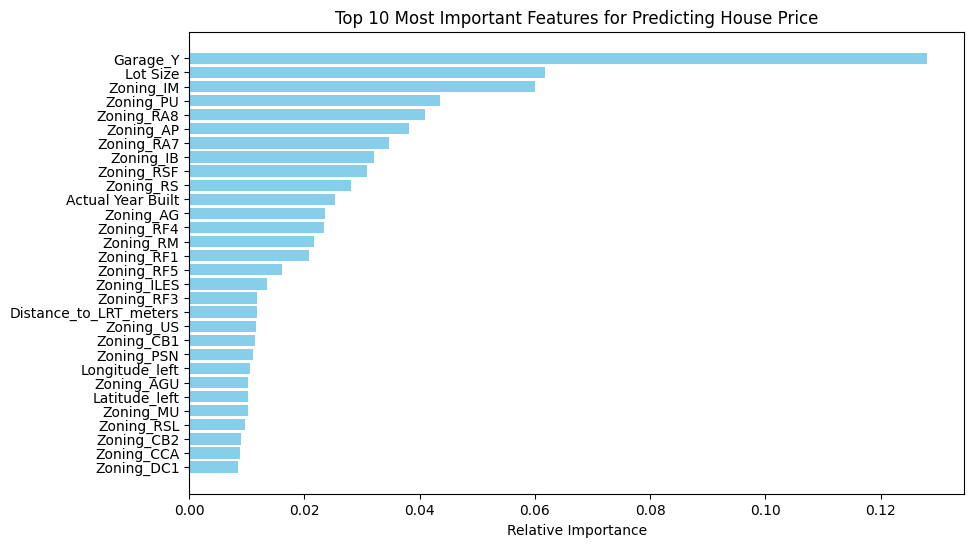

In [81]:
import matplotlib.pyplot as plt
import pandas as pd

# Extract the feature importances from the trained model
importances = model_v2.feature_importances_

# Create a DataFrame to match column names with their importance scores
feature_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': importances
})

# Sort them to find the top 10
top_10_features = feature_df.sort_values(by='Importance', ascending=False).head(30)

# Plot the results
plt.figure(figsize=(10, 6))
plt.barh(top_10_features['Feature'], top_10_features['Importance'], color='skyblue')
plt.gca().invert_yaxis() # Put the most important at the top
plt.title("Top 10 Most Important Features for Predicting House Price")
plt.xlabel("Relative Importance")
plt.show()

In [88]:
# 1. Grab the names of the top 30 features
top_cols = feature_df.sort_values(by='Importance', ascending=False).head(50)['Feature'].tolist()

# 2. Slice your training data to ONLY include those 30 columns
X_train_lean = X_train[top_cols]
X_test_lean = X_test[top_cols]

# 3. Retrain the model on the lean dataset
model_lean = XGBRegressor(n_estimators=500, learning_rate=0.1, random_state=42)
model_lean.fit(X_train_lean, y_train)

# 4. Evaluate
predictions_lean = model_lean.predict(X_test_lean)
mae_lean = mean_absolute_error(y_test, predictions_lean)
r2 = r2_score(y_test, predictions)

print(f"Lean Model MAE (Only 150 Features): ${mae_lean:,.2f}")
print(f"R-Squared (Accuracy Score): {r2:.3f}")

Lean Model MAE (Only 150 Features): $46,753.06
R-Squared (Accuracy Score): 0.838


In [109]:
# Keep only the middle 98% of the market
lower_bound = df_upgraded_ml['Assessed Value'].quantile(0.01)
upper_bound = df_upgraded_ml['Assessed Value'].quantile(0.99)

df_clean_v2 = df_upgraded_ml[(df_upgraded_ml['Assessed Value'] >= lower_bound) & 
                    (df_upgraded_ml['Assessed Value'] <= upper_bound)]

In [110]:
from sklearn.model_selection import train_test_split
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error

# 1. Split Features (X) and Target (y)
X = df_clean_v2.drop(columns=['Assessed Value'])
y = df_clean_v2['Assessed Value']

# 2. Train/Test Split (Use the same random_state=42 so it's a fair comparison!)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. Initialize and Train the Model
model_v3 = XGBRegressor(n_estimators=500, learning_rate=0.1, random_state=42)
model_v3.fit(X_train, y_train)

# 4. Predict and Evaluate
predictions_v3 = model_v3.predict(X_test)
mae_v3 = mean_absolute_error(y_test, predictions_v3)
r2 = r2_score(y_test, predictions_v3)

print(f"New MAE (With LRT Data): ${mae_v3:,.2f}")
print(f"R-Squared (Accuracy Score): {r2:.3f}")

New MAE (With LRT Data): $42,030.27
R-Squared (Accuracy Score): 0.853


Use log transformation trying to optimize

In [112]:
import numpy as np
from sklearn.model_selection import train_test_split
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, r2_score

# 1. Split Features (X) and Target (y)
X = df_clean_v2.drop(columns=['Assessed Value'])
y = df_clean_v2['Assessed Value']

# 2. Train/Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# --- THE LOG TRANSFORM MAGIC ---
# Convert the training prices into log values
y_train_log = np.log1p(y_train)

# 3. Initialize and Train the Model (Train on the log values!)
model_v3 = XGBRegressor(n_estimators=500, learning_rate=0.1, random_state=42)
model_v3.fit(X_train, y_train_log)

# 4. Predict and Evaluate
# The model will predict log values, so we reverse them back to real dollars
predictions_v3_log = model_v3.predict(X_test)
predictions_v3_real = np.expm1(predictions_v3_log)

# Calculate error comparing the reversed predictions to the original real test prices
mae_v3 = mean_absolute_error(y_test, predictions_v3_real)
r2 = r2_score(y_test, predictions_v3_real)

print(f"Log-Transformed MAE: ${mae_v3:,.2f}")
print(f"R-Squared: {r2:.3f}")

Log-Transformed MAE: $41,878.22
R-Squared: 0.839


In [113]:
from sklearn.model_selection import RandomizedSearchCV
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, r2_score
import numpy as np

# 1. Define the parameters to test
param_grid = {
    'max_depth': [5, 7, 9, 11],         # Deeper trees map the coordinates better
    'learning_rate': [0.01, 0.05, 0.1], # Slower learning prevents memorizing noise
    'subsample': [0.7, 0.8, 0.9],       # % of data used per tree (prevents overfitting)
    'n_estimators': [300, 500, 800]     # Number of trees
}

# 2. Initialize a blank base model
base_model = XGBRegressor(random_state=42)

# 3. Set up the Searcher
# n_iter=10 tests 10 random combinations. cv=3 double-checks the work 3 times.
random_search = RandomizedSearchCV(
    estimator=base_model, 
    param_distributions=param_grid, 
    n_iter=10, 
    scoring='r2',       # Tell it to focus on fixing the R-Squared!
    cv=3, 
    verbose=2,          # Prints progress so you aren't staring at a blank screen
    n_jobs=-1,          # Uses all CPU cores
    random_state=42
)

# 4. Run the Search (Train on the log prices!)
print("Starting hyperparameter tuning...")
random_search.fit(X_train, y_train_log)

# 5. Extract the Winner
best_model = random_search.best_estimator_
print(f"\n✅ Best Parameters Found: {random_search.best_params_}")

# 6. Predict and Evaluate
predictions_log = best_model.predict(X_test)
predictions_real = np.expm1(predictions_log)

final_mae = mean_absolute_error(y_test, predictions_real)
final_r2 = r2_score(y_test, predictions_real)

print(f"Tuned MAE: ${final_mae:,.2f}")
print(f"Tuned R-Squared: {final_r2:.4f}")

Starting hyperparameter tuning...
Fitting 3 folds for each of 10 candidates, totalling 30 fits
[CV] END learning_rate=0.1, max_depth=7, n_estimators=300, subsample=0.9; total time=12.6min
[CV] END learning_rate=0.1, max_depth=5, n_estimators=500, subsample=0.9; total time=18.3min
[CV] END learning_rate=0.1, max_depth=5, n_estimators=500, subsample=0.9; total time=18.6min
[CV] END learning_rate=0.1, max_depth=5, n_estimators=500, subsample=0.9; total time=18.9min
[CV] END learning_rate=0.01, max_depth=7, n_estimators=300, subsample=0.8; total time=20.6min
[CV] END learning_rate=0.01, max_depth=7, n_estimators=300, subsample=0.8; total time=21.3min
[CV] END learning_rate=0.01, max_depth=7, n_estimators=300, subsample=0.8; total time=21.8min
[CV] END learning_rate=0.1, max_depth=7, n_estimators=300, subsample=0.9; total time=13.6min
[CV] END learning_rate=0.01, max_depth=5, n_estimators=500, subsample=0.8; total time=29.0min
[CV] END learning_rate=0.01, max_depth=5, n_estimators=500, subs

In [114]:
import joblib

# 1. Save the highly-tuned model
joblib.dump(best_model, 'data/edmonton_xgboost_log_model.pkl')

# 2. Save the column list (Crucial for your Django API!)
joblib.dump(list(X_train.columns), 'data/model_columns.pkl')

print("✅ Master Model Saved.")

✅ Master Model Saved. Ready for Web Deployment!
